# Prompt Engineering for Dialogue Summarization

This notebook implements a small dialogue summarization pipeline using a pretrained transformer model. It compares a simple baseline prompt with an improved, outcome‑focused prompt on a subset of SAMSum dialogues and evaluates both summary quality (ROUGE‑L) and efficiency.

## Environment and Project Setup

This section prepares the Python environment and configures imports:

- Imports core libraries for timing (`time`), tensor operations (`torch`), data handling (`pandas`, `numpy`), and visualization (`matplotlib`).
- Loads the ROUGE metric from the `evaluate` library for automatic summary evaluation.
- Computes the **project root** directory (one level above the current working directory) and appends it to `sys.path` so that helper modules in the `src/` package can be imported.
- Imports custom helper functions:
  - `load_samsum_subset` to load a small evaluation subset of the SAMSum dialogue dataset.
  - `load_summarization_pipeline` and `generate_summary` to initialize the pretrained model and generate summaries with different prompt styles.

The printed project root confirms that the notebook is running inside the expected repository folder.

## Loading the Summarization Pipeline

With the project root configured, the next step is to initialize the dialogue summarization pipeline and load the evaluation data:

- `load_summarization_pipeline()` constructs a pretrained transformer‑based summarization pipeline (using the Microsoft Phi‑2 model under the hood), moves it to the available device (CPU or GPU), and returns a small dictionary with the tokenizer, model, and device.
- `load_samsum_subset()` will later be used to load a small subset of SAMSum dialogues and their reference summaries for evaluation.

The printed project root (`C:\Users\nlope\Desktop\week3\generative_transformer_project`) confirms that imports from the `src` package will resolve correctly for the rest of the notebook.

In [1]:
# Cell 1: Imports and project root setup

import os
import sys
import time

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evaluate import load  # Hugging Face evaluate library for ROUGE

# Add project root to sys.path so we can import from src/
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

# Now we can import our project-specific helpers
from src.data import load_samsum_subset
from src.model import load_summarization_pipeline, generate_summary

Project root: C:\Users\nlope\Desktop\week3\generative_transformer_project


In [3]:
# Cell 2: Load pretrained summarization pipeline (Phi-2 under the hood)

# load_summarization_pipeline() should:
# - Load the Microsoft Phi-2 model and tokenizer
# - Move the model to the right device (CPU/GPU)
# - Return a small dict with tokenizer, model, and device
gen = load_summarization_pipeline()

# Inspect keys just to confirm what the pipeline contains
print("Pipeline keys:", gen.keys())

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Pipeline keys: dict_keys(['tokenizer', 'model', 'device'])


## Initializing the Pretrained Summarization Model

The next step is to load the pretrained transformer model that will generate dialogue summaries.

- `load_summarization_pipeline()` loads the **Microsoft Phi‑2** language model and its tokenizer through the project’s helper code.
- The model is moved to the available device (CPU or GPU), and the function returns a small dictionary containing:
  - `tokenizer` – the text tokenizer used to encode and decode dialogues.
  - `model` – the pretrained Phi‑2 model used for generation.
  - `device` – the compute device where the model is running.

The log line “Loading weights: 100% (453/453)” shows that all model weights were loaded successfully, and the printed keys confirm that the pipeline exposes the expected components.

## Loading SAMSum Evaluation Dialogues

To evaluate the prompts, the notebook loads a small subset of the **SAMSum** dialogue dataset:

- `load_samsum_subset(num_examples=3)` returns three short, messenger‑style conversations (`dialogs`) and their corresponding human‑written summaries (`refs`).
- These three examples are chosen to cover different situations, such as meeting scheduling, homework reminders, and technical incident response.

The printed output confirms that three examples were loaded and shows the full text of the first dialogue along with its reference summary, which will be used as a gold standard for comparison.

In [4]:
# Cell 3: Load a small SAMSum subset and inspect the first example

dialogs, refs = load_samsum_subset(num_examples=3)

print("Number of examples:", len(dialogs))
print("\n=== Example 1 dialogue ===\n", dialogs[0])
print("\n=== Example 1 reference ===\n", refs[0])

Number of examples: 3

=== Example 1 dialogue ===
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

=== Example 1 reference ===
 Sam and Alex reschedule their meeting from 3:00 to 3:30.


## ROUGE‑L Metric Setup

To quantify summary quality, this notebook uses the ROUGE metric from the `evaluate` library:

- `load("rouge")` returns an evaluation module that can compute several ROUGE variants, including **ROUGE‑1**, **ROUGE‑2**, **ROUGE‑L**, and **ROUGE‑Lsum**.
- The printed description shows the expected inputs (`predictions` and `references`) and confirms that `rougeL` is reported as an F1‑style score.

Four Python lists are initialized to store experiment outputs:

- `baseline_preds` and `improved_preds` will hold the generated summaries for each dialogue.
- `baseline_scores` and `improved_scores` will hold the corresponding **ROUGE‑L** scores.

These structures make it easy to compare baseline versus improved prompts across all dialogue examples.

In [5]:
# Cell 4: Prepare ROUGE metric and storage for predictions / scores

# Load ROUGE metric from the evaluate library
metric = load("rouge")
print("Loaded metric:", metric)

# Lists to store generated summaries and ROUGE-L scores
baseline_preds = []
improved_preds = []
baseline_scores = []
improved_scores = []

Loaded metric: EvaluationModule(name: "rouge", module_type: "metric", features: [{'predictions': Value('string'), 'references': List(Value('string'))}, {'predictions': Value('string'), 'references': Value('string')}], usage: """
Calculates average rouge scores for a list of hypotheses and references
Args:
    predictions: list of predictions to score. Each prediction
        should be a string with tokens separated by spaces.
    references: list of reference for each prediction. Each
        reference should be a string with tokens separated by spaces.
    rouge_types: A list of rouge types to calculate.
        Valid names:
        `"rouge{n}"` (e.g. `"rouge1"`, `"rouge2"`) where: {n} is the n-gram based scoring,
        `"rougeL"`: Longest common subsequence based scoring.
        `"rougeLsum"`: rougeLsum splits text using `"
"`.
        See details in https://github.com/huggingface/datasets/issues/617
    use_stemmer: Bool indicating whether Porter stemmer should be used to strip w

## Baseline vs Improved Prompt Experiment

This cell runs the core summarization experiment on the three SAMSum dialogues:

- For each dialogue–reference pair, the notebook generates **two** summaries:
  - A **baseline** summary using a simple, single‑sentence prompt.
  - An **improved** summary using an outcome‑focused prompt that emphasizes faithful, concise descriptions.
- Both summaries are generated with the same decoding settings (`max_new_tokens = 60`, `temperature = 0.3`) so that differences in quality are mainly due to **prompt wording**, not randomness.
- The generated summaries are stored in `baseline_preds` and `improved_preds`, and ROUGE‑L scores are computed with the `evaluate` metric and stored in `baseline_scores` and `improved_scores`.

The loop also prints, for each of the three examples:

- The original **dialogue**.
- The **reference** human summary.
- The **baseline** model summary.
- The **improved** model summary.
- The **ROUGE‑L** scores for both prompts.

These printed examples make it easy to see when the improved prompt helps (for instance, in the meeting rescheduling dialogue) and when it hurts by omitting key actions (as in the deployment‑failure dialogue).

In [6]:
# Cell 5: Generate baseline and improved summaries and compute ROUGE-L

for i, (dialogue, reference) in enumerate(zip(dialogs, refs), start=1):
    # Generate summary with the baseline prompt
    baseline = generate_summary(
        gen,
        dialogue,
        prompt_style="baseline",
        max_new_tokens=60,
        temperature=0.3,  # low temperature for more deterministic output
    )

    # Generate summary with the improved, outcome-focused prompt
    improved = generate_summary(
        gen,
        dialogue,
        prompt_style="improved",
        max_new_tokens=60,
        temperature=0.3,  # same temperature to isolate prompt wording
    )

    # Save text outputs
    baseline_preds.append(baseline)
    improved_preds.append(improved)

    # Compute ROUGE-L scores for this example
    base_result = metric.compute(predictions=[baseline], references=[reference])
    imp_result = metric.compute(predictions=[improved], references=[reference])

    # In this setting, metric.compute returns a dict of floats; we take rougeL
    base_f1 = float(base_result["rougeL"])
    imp_f1 = float(imp_result["rougeL"])

    baseline_scores.append(base_f1)
    improved_scores.append(imp_f1)

    # Print everything so the video shows real generation and scores
    print(f"\n=== Example {i} ===")
    print("DIALOGUE:\n", dialogue)
    print("\nREFERENCE:\n", reference)
    print("\nBASELINE:\n", baseline)
    print("\nIMPROVED:\n", improved)
    print(f"\nBaseline ROUGE-L:  {base_f1:.3f}")
    print(f"Improved ROUGE-L:  {imp_f1:.3f}")
    print("-" * 80)


=== Example 1 ===
DIALOGUE:
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

REFERENCE:
 Sam and Alex reschedule their meeting from 3:00 to 3:30.

BASELINE:
 Sam and Alex agree to meet at 3:30 for the meeting.

IMPROVED:
 Answer: Sam and Alex agreed to move the meeting to 3:30.

Baseline ROUGE-L:  0.500
Improved ROUGE-L:  0.583
--------------------------------------------------------------------------------

=== Example 2 ===
DIALOGUE:
 Mom: Did you finish your homework?
Kid: Almost, I have one assignment left.
Mom: Please finish before dinner.
Kid: Okay, I will.

REFERENCE:
 A mother reminds her child to finish homework before dinner.

BASELINE:
 The kid has one homework assignment left and will finish it before dinner.

IMPROVED:
 Possible summary: - Kid almost finished homework, but needs to hurry for dinner.

Baseline ROUGE-L:  0.261
Improved ROUGE-L:  0.182
---------------------------------

## Runtime and Efficiency Measurement

To understand the efficiency of the prompting‑only summarization pipeline, this cell measures end‑to‑end latency:

- The notebook re‑runs the full generation and evaluation loop for all three dialogues, using both the baseline and improved prompts.
- A timer (`time.time()`) records the wall‑clock time before and after the loop to capture the total runtime.
- The code reports:
  - **Total time (seconds)** for generating all six summaries (baseline + improved for three dialogues) and computing ROUGE‑L.
  - **Average time per example (seconds)**, obtained by dividing the total time by the number of dialogues.

In this run, the pipeline takes approximately **29.36 seconds** in total, or about **9.79 seconds per dialogue**, which is acceptable for offline experiments but would be relatively slow for a real‑time, interactive summarization system without further optimization or batching.

In [8]:
# Cell 6: Measure end-to-end latency for generating and evaluating summaries

start = time.time()

# Re-run generation + evaluation to measure realistic latency
baseline_preds = []
improved_preds = []
baseline_scores = []
improved_scores = []

for i, (dialogue, reference) in enumerate(zip(dialogs, refs), start=1):
    baseline = generate_summary(
        gen,
        dialogue,
        prompt_style="baseline",
        max_new_tokens=60,
        temperature=0.3,
    )
    improved = generate_summary(
        gen,
        dialogue,
        prompt_style="improved",
        max_new_tokens=60,
        temperature=0.3,
    )

    baseline_preds.append(baseline)
    improved_preds.append(improved)

    base_result = metric.compute(predictions=[baseline], references=[reference])
    imp_result = metric.compute(predictions=[improved], references=[reference])

    base_f1 = float(base_result["rougeL"])
    imp_f1 = float(imp_result["rougeL"])

    baseline_scores.append(base_f1)
    improved_scores.append(imp_f1)

end = time.time()
elapsed = end - start

print("\nTotal time (s):", elapsed)
print("Avg time per example (s):", elapsed / len(dialogs))


Total time (s): 29.364667177200317
Avg time per example (s): 9.788222392400106


## Structured Results Table

After generating and timing the summaries, the notebook collects all experiment outputs into a `pandas` DataFrame. Each row corresponds to one SAMSum dialogue example, and each column has the following meaning:

- `dialogue` – The full multi‑turn messenger‑style conversation for the example.
- `reference` – The human‑written abstractive summary provided by the SAMSum dataset.
- `baseline_summary` – The model’s summary generated with the simple baseline prompt.
- `improved_summary` – The model’s summary generated with the outcome‑focused prompt.
- `baseline_rougeL` – The ROUGE‑L score for the baseline summary compared to the reference.
- `improved_rougeL` – The ROUGE‑L score for the improved summary compared to the reference.

Printing the DataFrame gives a compact, tabular view of how the two prompt strategies perform on each dialogue and prepares the results to be saved for later analysis.

In [9]:
# Cell 7: Build a DataFrame with dialogues, references, summaries, and ROUGE-L

df = pd.DataFrame({
    "dialogue": dialogs,
    "reference": refs,
    "baseline_summary": baseline_preds,
    "improved_summary": improved_preds,
    "baseline_rougeL": baseline_scores,
    "improved_rougeL": improved_scores,
})

print(df)

                                            dialogue  \
0  Sam: Hey, are we still on for the meeting at 3...   
1  Mom: Did you finish your homework?\nKid: Almos...   
2  Alice: The deployment failed again.\nBob: I sa...   

                                           reference  \
0  Sam and Alex reschedule their meeting from 3:0...   
1  A mother reminds her child to finish homework ...   
2  Alice and Bob handle a failed deployment by ro...   

                                    baseline_summary  \
0  Sam and Alex agree to postpone the meeting to ...   
1  Possible summary: - The kid is almost done wit...   
2  Possible summary: - Alice and Bob encountered ...   

                                    improved_summary  baseline_rougeL  \
0                      The meeting is moved to 3:30.         0.608696   
1  Possible summary: - Kid finishes homework befo...         0.217391   
2  The deployment failed due to a database migrat...         0.411765   

   improved_rougeL  
0         0

## Saving Results to CSV

To make the experiment reproducible and easy to inspect outside the notebook, the results are exported to disk:

- The `results` directory is created if it does not already exist.
- The DataFrame containing dialogues, references, generated summaries, and ROUGE‑L scores is written to `summarization_results.csv` inside the project’s `results/` folder.
- The printed path confirms where the CSV file was saved:

  `C:\Users\nlope\Desktop\week3\generative_transformer_project\results\summarization_results.csv`

This CSV is the main artifact used in the written report and can be loaded later for additional analysis or visualization.

In [10]:
# Cell 8: Save results CSV to the results/ folder

results_dir = r"C:\Users\nlope\Desktop\week3\generative_transformer_project\results"

# Ensure the results directory exists (create it if needed)
os.makedirs(results_dir, exist_ok=True)

csv_path = os.path.join(results_dir, "summarization_results.csv")
df.to_csv(csv_path, index=False)

print(f"Saved CSV: {csv_path}")

Saved CSV: C:\Users\nlope\Desktop\week3\generative_transformer_project\results\summarization_results.csv


## Visualizing ROUGE‑L Scores

To better compare how the two prompts perform on each dialogue, this cell creates a bar chart:

- The x‑axis indexes the three dialogue examples (1, 2, and 3).
- The y‑axis shows the **ROUGE‑L** score.
- Blue bars represent the **baseline** prompt scores.
- Orange bars represent the **improved** prompt scores.

The bars are plotted side‑by‑side for each example so it is easy to see where the improved prompt helps and where it hurts. The figure is saved as `rouge_bar.png` in the `results/` folder and is also used in the project report to illustrate the prompt‑level performance differences.

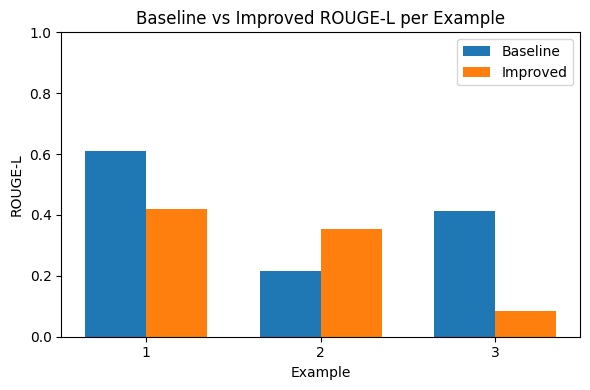

Saved plot: C:\Users\nlope\Desktop\week3\generative_transformer_project\results\rouge_bar.png


In [11]:
# Cell 9: Plot baseline vs improved ROUGE-L and save as PNG

examples = np.arange(len(df)) + 1  # [1, 2, 3] for three dialogues

plt.figure(figsize=(6, 4))
width = 0.35

# Side-by-side bars for each example
plt.bar(examples - width / 2, df["baseline_rougeL"], width, label="Baseline")
plt.bar(examples + width / 2, df["improved_rougeL"], width, label="Improved")

plt.xlabel("Example")
plt.ylabel("ROUGE-L")
plt.title("Baseline vs Improved ROUGE-L per Example")
plt.xticks(examples)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

plot_path = os.path.join(results_dir, "rouge_bar.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved plot: {plot_path}")

## Conclusion

This notebook demonstrates a prompt‑engineering approach to dialogue summarization using a pretrained transformer model. By comparing a simple baseline prompt with an outcome‑focused prompt on three SAMSum dialogues, it shows that improved prompts can sometimes increase ROUGE‑L scores and produce more concise summaries, but they can also omit important details and reduce alignment with human references. The saved CSV and ROUGE‑L plot provide reusable artifacts for the written report and future experiments.